In [2]:
# Install Ultralytics
!pip install -q ultralytics

import ultralytics
print("Ultralytics Version:", ultralytics.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics Version: 8.4.102


In [3]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

from ultralytics import YOLO

import torch

print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using Device:", device)

Torch Version: 2.11.0+cu128
CUDA Available: True
Using Device: cuda


In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
DATASET_PATH = "/content/drive/MyDrive/Mammogram_Shape_Preprocess"

YOLO_PATH = os.path.join(DATASET_PATH, "YOLO_dataset")

YAML_PATH = os.path.join(YOLO_PATH, "dataset.yaml")

print(YAML_PATH)

/content/drive/MyDrive/Mammogram_Shape_Preprocess/YOLO_dataset/dataset.yaml


In [7]:
for split in ["train", "val", "test"]:

    img_dir = os.path.join(YOLO_PATH, "images", split)
    lbl_dir = os.path.join(YOLO_PATH, "labels", split)

    print(f"\n{split.upper()}")

    print("Images :", len(os.listdir(img_dir)))
    print("Labels :", len(os.listdir(lbl_dir)))


TRAIN
Images : 1004
Labels : 1004

VAL
Images : 126
Labels : 126

TEST
Images : 130
Labels : 130


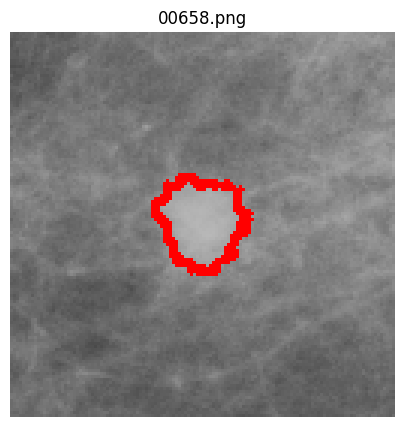

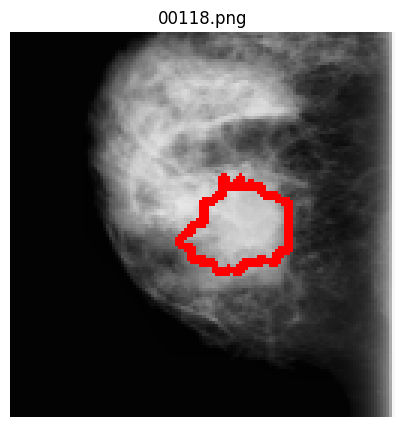

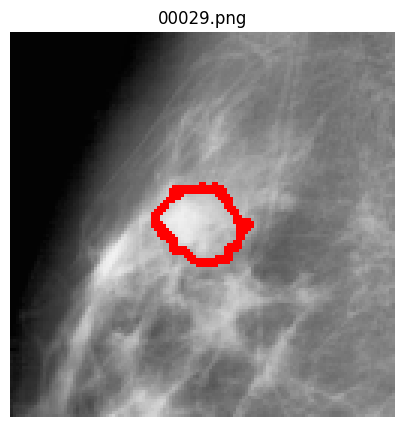

In [8]:
def visualize_sample(split="train"):
    img_dir = os.path.join(YOLO_PATH, "images", split)
    lbl_dir = os.path.join(YOLO_PATH, "labels", split)

    image_name = random.choice(os.listdir(img_dir))

    img = cv2.imread(os.path.join(img_dir, image_name), cv2.IMREAD_GRAYSCALE)
    overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    h, w = img.shape

    label_file = os.path.join(lbl_dir, image_name.replace(".png", ".txt"))

    with open(label_file, "r") as f:
        for line in f:
            values = line.strip().split()

            if len(values) < 7:
                continue

            points = np.array(values[1:], dtype=np.float32).reshape(-1,2)

            points[:,0] *= w
            points[:,1] *= h

            points = points.astype(np.int32)

            cv2.polylines(
                overlay,
                [points],
                isClosed=True,
                color=(255,0,0),
                thickness=2
            )

    plt.figure(figsize=(5,5))
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(image_name)
    plt.show()

for _ in range(3):
    visualize_sample("train")

In [9]:
model = YOLO("yolo11m-seg.pt")
model.info()

YOLO11m-seg summary: 253 layers, 22,420,896 parameters, 0 gradients, 113.9 GFLOPs


(253, 22420896, 0, 113.8534912)

In [10]:
Y_test = np.load(os.path.join(DATASET_PATH, "NEW_ROI_Y_test.npy"))

print(Y_test.shape)

(130, 128, 128, 1)


In [11]:
results = model.train(
    data=YAML_PATH,

    epochs=100,
    imgsz=128,
    batch=16,

    optimizer="AdamW",

    lr0=5e-4,

    weight_decay=5e-4,

    patience=20,

    degrees=5,
    translate=0.05,
    scale=0.20,
    fliplr=0.5,
    flipud=0.5,

    mosaic=0.0,
    mixup=0.0,

    workers=2,

    project="YOLO_Breast",

    name="YOLO11_SEG",

    pretrained=True,
    save=True,
    verbose=True,
    seed=42
)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Mammogram_Shape_Preprocess/YOLO_dataset/dataset.yaml, degrees=5, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-seg.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=YOLO11_SEG, nbs=64, nms=False, op

In [12]:
best_model_path = "/content/runs/segment/YOLO_Breast/YOLO11_SEG/weights/best.pt"

best_model = YOLO(best_model_path)

print("Best model loaded successfully!")

Best model loaded successfully!


In [13]:
metrics = best_model.val(
    data=YAML_PATH,
    split="test",
    imgsz=128,
    batch=16
)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m-seg summary (fused): 139 layers, 22,336,083 parameters, 0 gradients, 112.9 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 1.1±0.6 ms, read: 1.1±2.5 MB/s, size: 8.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/.shortcut-targets-by-id/1__Vswd3cxzZ3JpClOjiLWhZl6VNIpkoT/Mammogram_Shape_Preprocess/YOLO_dataset/labels/test.cache... 130 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 36.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 5.0it/s 1.8s
                   all        130        130       0.89      0.908      0.926      0.541      0.899        0.9      0.922      0.439
Speed: 0.1ms preprocess, 6.0ms inference, 0.0ms loss, 2.6ms pos

In [14]:
print("========== YOLO Segmentation Metrics ==========")

print(f"Mask mAP50     : {metrics.seg.map50:.4f}")
print(f"Mask mAP50-95  : {metrics.seg.map:.4f}")

print(f"Precision      : {metrics.seg.mp:.4f}")
print(f"Recall         : {metrics.seg.mr:.4f}")

========== YOLO Segmentation Metrics ==========
Mask mAP50     : 0.9223
Mask mAP50-95  : 0.4386
Precision      : 0.8995
Recall         : 0.9000


In [15]:
results = best_model.predict(
    source=os.path.join(YOLO_PATH, "images", "test"),
    imgsz=128,
    conf=0.10,
    save=True,
    save_txt=False,
    retina_masks=True
)


image 1/130 /content/drive/MyDrive/Mammogram_Shape_Preprocess/YOLO_dataset/images/test/00000.png: 128x128 1 lesion, 12.6ms
image 2/130 /content/drive/MyDrive/Mammogram_Shape_Preprocess/YOLO_dataset/images/test/00001.png: 128x128 1 lesion, 19.2ms
image 3/130 /content/drive/MyDrive/Mammogram_Shape_Preprocess/YOLO_dataset/images/test/00002.png: 128x128 1 lesion, 13.9ms
image 4/130 /content/drive/MyDrive/Mammogram_Shape_Preprocess/YOLO_dataset/images/test/00003.png: 128x128 1 lesion, 12.2ms
image 5/130 /content/drive/MyDrive/Mammogram_Shape_Preprocess/YOLO_dataset/images/test/00004.png: 128x128 1 lesion, 13.8ms
image 6/130 /content/drive/MyDrive/Mammogram_Shape_Preprocess/YOLO_dataset/images/test/00005.png: 128x128 1 lesion, 12.8ms
image 7/130 /content/drive/MyDrive/Mammogram_Shape_Preprocess/YOLO_dataset/images/test/00006.png: 128x128 3 lesions, 15.5ms
image 8/130 /content/drive/MyDrive/Mammogram_Shape_Preprocess/YOLO_dataset/images/test/00007.png: 128x128 5 lesions, 12.2ms
image 9/130 /

In [16]:
def dice_score(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred).sum()
    return (2.0 * intersection) / (y_true.sum() + y_pred.sum() + 1e-7)


def iou_score(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    return intersection / (union + 1e-7)


def precision_score(y_true, y_pred):
    TP = np.logical_and(y_true == 1, y_pred == 1).sum()
    FP = np.logical_and(y_true == 0, y_pred == 1).sum()

    return TP / (TP + FP + 1e-7)


def recall_score(y_true, y_pred):
    TP = np.logical_and(y_true == 1, y_pred == 1).sum()
    FN = np.logical_and(y_true == 1, y_pred == 0).sum()

    return TP / (TP + FN + 1e-7)


def f1_score(y_true, y_pred):
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)

    return 2 * p * r / (p + r + 1e-7)


def pixel_accuracy(y_true, y_pred):
    return (y_true == y_pred).sum() / y_true.size


def predict_with_fallback(model, image_path, imgsz=128, primary_conf=0.25, fallback_conf=0.001):
    result = model.predict(image_path, imgsz=imgsz, conf=primary_conf, verbose=False)[0]

    if result.masks is None:
        result = model.predict(image_path, imgsz=imgsz, conf=fallback_conf, verbose=False)[0]

        if result.masks is not None and len(result.boxes) > 0:
            best_idx = int(result.boxes.conf.argmax().item())
            result.masks.data = result.masks.data[best_idx:best_idx + 1]
            result.boxes = result.boxes[best_idx:best_idx + 1]

    return result

In [17]:
from tqdm import tqdm

test_image_dir = os.path.join(YOLO_PATH, "images", "test")
image_files = sorted(os.listdir(test_image_dir))

dice = []
iou = []
precision = []
recall = []
f1 = []
accuracy = []

predictions = []

for i, image_name in enumerate(tqdm(image_files)):

    image_path = os.path.join(test_image_dir, image_name)

    result = predict_with_fallback(
        best_model,
        image_path,
        imgsz=128,
        primary_conf=0.10,
        fallback_conf=0.0001
    )

    pred_mask = np.zeros((128,128), dtype=np.uint8)

    if result.masks is not None:

        masks = result.masks.data.cpu().numpy()

        # Keep only the largest predicted lesion
        areas = [m.sum() for m in masks]
        largest = masks[np.argmax(areas)]

        pred_mask = (largest > 0.5).astype(np.uint8)

        # Fill small holes
        kernel = np.ones((5,5), np.uint8)
        pred_mask = cv2.morphologyEx(
            pred_mask,
            cv2.MORPH_CLOSE,
            kernel
        )

        # Remove tiny false positives
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(pred_mask)

        clean = np.zeros_like(pred_mask)

        for j in range(1, num_labels):
            if stats[j, cv2.CC_STAT_AREA] > 40:
                clean[labels == j] = 1

        pred_mask = clean

    predictions.append(pred_mask)

    gt_mask = Y_test[i].squeeze().astype(np.uint8)

    dice.append(dice_score(gt_mask, pred_mask))
    iou.append(iou_score(gt_mask, pred_mask))
    precision.append(precision_score(gt_mask, pred_mask))
    recall.append(recall_score(gt_mask, pred_mask))
    f1.append(f1_score(gt_mask, pred_mask))
    accuracy.append(pixel_accuracy(gt_mask, pred_mask))

100%|██████████| 130/130 [00:03<00:00, 35.99it/s]


In [18]:
import pandas as pd

dice_scores = np.array(dice)

df = pd.DataFrame({
    "Image": image_files,
    "Dice": dice_scores
})

df = df.sort_values("Dice")

print(df.head(20))

         Image      Dice
27   00027.png  0.000000
16   00016.png  0.000000
45   00045.png  0.000000
106  00106.png  0.000000
116  00116.png  0.000000
109  00109.png  0.000000
82   00082.png  0.008364
20   00020.png  0.034423
63   00063.png  0.116849
15   00015.png  0.133260
99   00099.png  0.357635
8    00008.png  0.391374
48   00048.png  0.556558
120  00120.png  0.567376
33   00033.png  0.577551
24   00024.png  0.580210
46   00046.png  0.606811
36   00036.png  0.612500
83   00083.png  0.642416
76   00076.png  0.650730


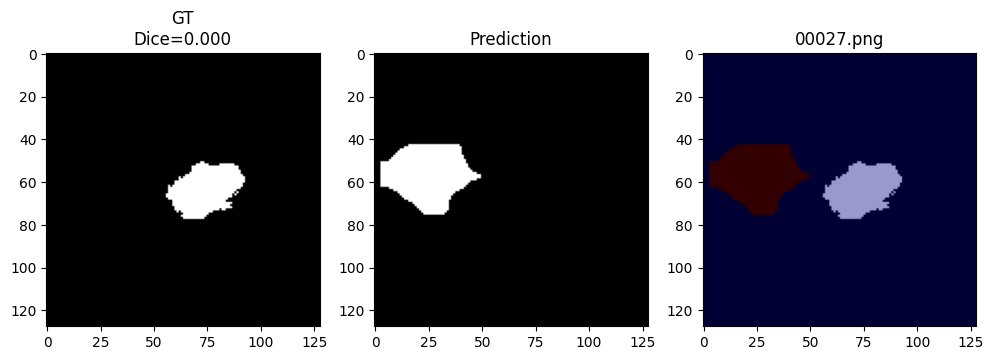

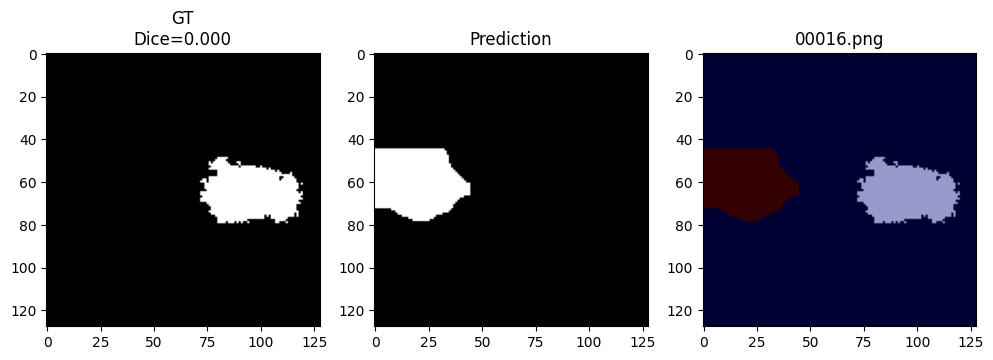

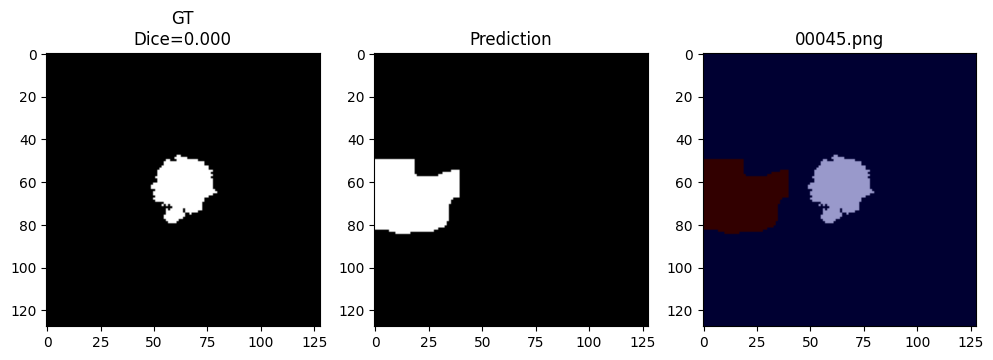

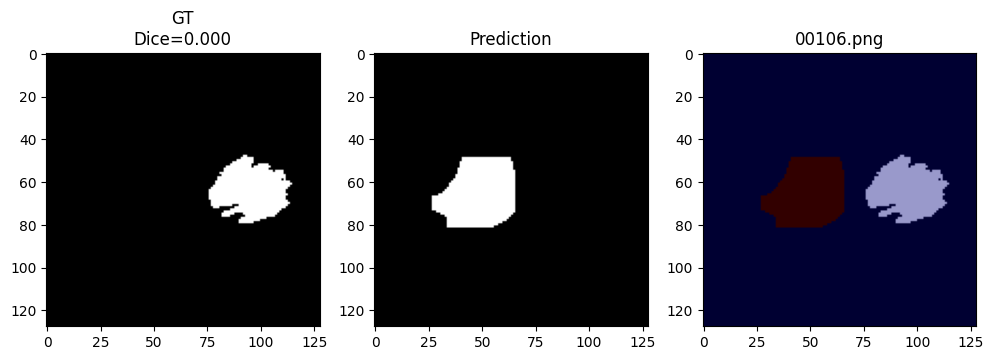

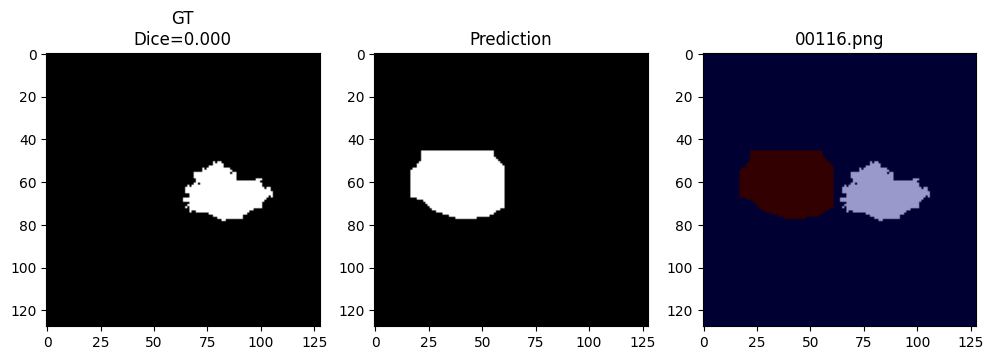

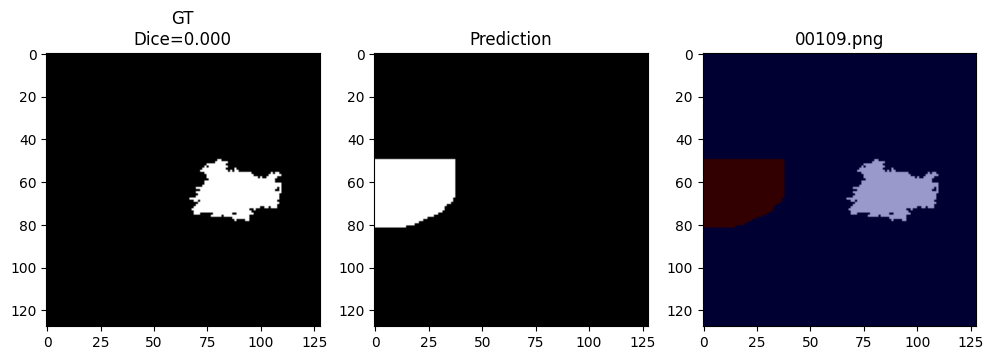

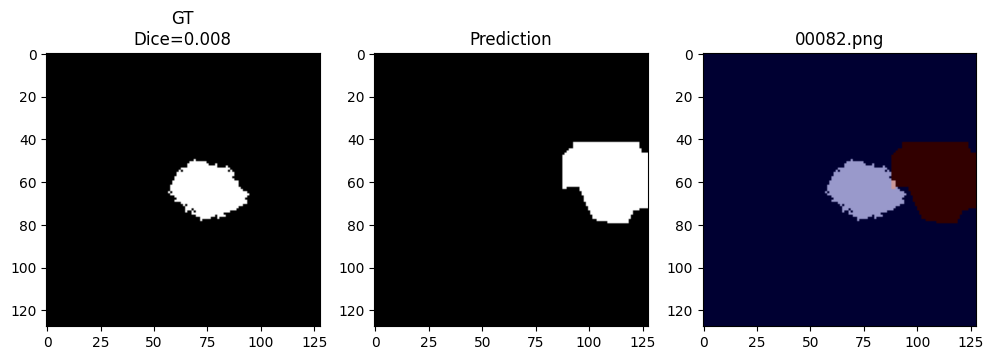

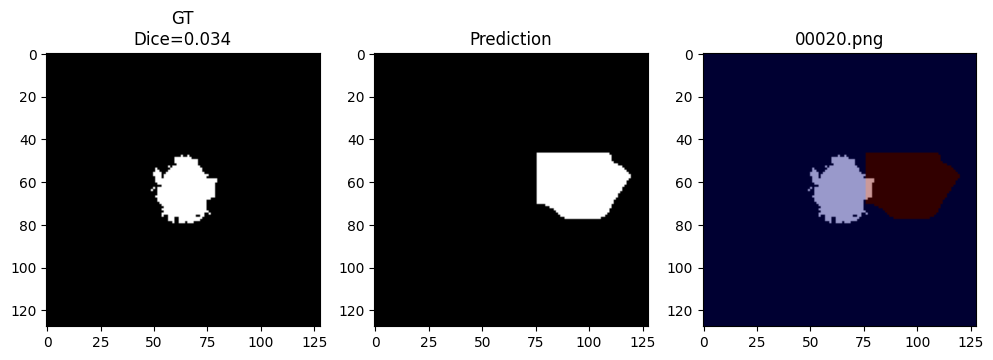

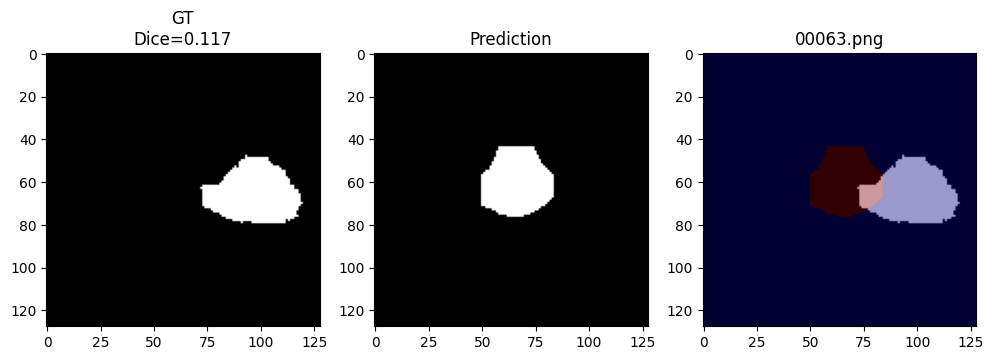

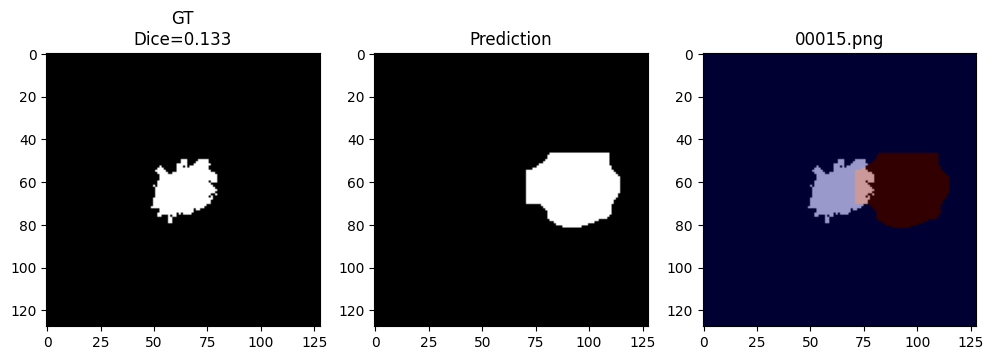

In [19]:
worst = np.argsort(dice_scores)[:10]

for idx in worst:

    gt = Y_test[idx].squeeze()

    pred = predictions[idx]

    plt.figure(figsize=(12,4))

    plt.subplot(131)
    plt.imshow(gt, cmap="gray")
    plt.title(f"GT\nDice={dice_scores[idx]:.3f}")

    plt.subplot(132)
    plt.imshow(pred, cmap="gray")
    plt.title("Prediction")

    plt.subplot(133)
    plt.imshow(gt, cmap="gray")
    plt.imshow(pred, alpha=0.4, cmap="jet")
    plt.title(image_files[idx])

    plt.show()

In [20]:
print("Minimum Dice :", np.min(dice))
print("Maximum Dice :", np.max(dice))
print("Mean Dice    :", np.mean(dice))
print("Median Dice  :", np.median(dice))
print("Images with Dice < 0.5 :", np.sum(np.array(dice) < 0.5))
print("Images with Dice < 0.3 :", np.sum(np.array(dice) < 0.3))

Minimum Dice : 0.0
Maximum Dice : 0.9078097474510974
Mean Dice    : 0.7233569079826417
Median Dice  : 0.78790152268737
Images with Dice < 0.5 : 12
Images with Dice < 0.3 : 10


In [21]:
results_df = pd.DataFrame({
    "Metric":[
        "Dice",
        "IoU",
        "Precision",
        "Recall",
        "F1-score",
        "Pixel Accuracy"
    ],
    "YOLO11":[
        np.mean(dice),
        np.mean(iou),
        np.mean(precision),
        np.mean(recall),
        np.mean(f1),
        np.mean(accuracy)
    ]
})

results_df

,Metric,YOLO11
0,Dice,0.723357
1,IoU,0.601012
2,Precision,0.631025
3,Recall,0.859817
4,F1-score,0.723357
5,Pixel Accuracy,0.972748


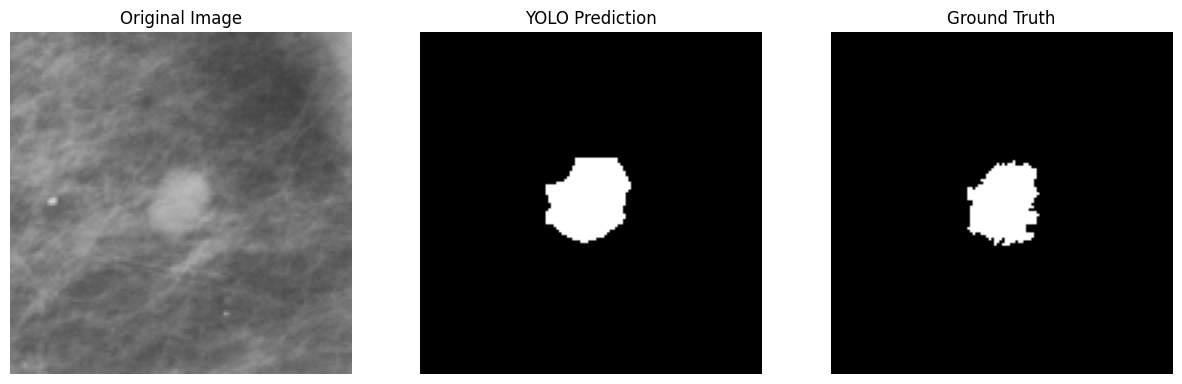

In [22]:
idx = random.randint(0, len(results)-1)

result = results[idx]

img = result.orig_img

if result.masks is not None:
    pred_mask = result.masks.data[0].cpu().numpy()
else:
    pred_mask = np.zeros((128,128))

gt_mask = Y_test[idx].squeeze()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(pred_mask, cmap="gray")
plt.title("YOLO Prediction")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(gt_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.show()

In [36]:
# ── Load the real shape labels for the test set ──
shape_test_raw = np.load(os.path.join(DATASET_PATH, "roi_shape_test.npy"), allow_pickle=True)

print("dtype:", shape_test_raw.dtype, "| shape:", shape_test_raw.shape)
print("unique values:", np.unique(shape_test_raw))

assert len(shape_test_raw) == len(dice), (
    f"Length mismatch: roi_shape_test.npy has {len(shape_test_raw)} entries, "
    f"but {len(dice)} test images were scored. Check that roi_shape_test.npy "
    "is aligned with the same test split/order as image_files."
)
SHAPE_ID_TO_NAME = {0: "irregular", 1: "oval", 2: "lobulated"}

def shape_label(v):
    if isinstance(v, (bytes, np.bytes_)):
        v = v.decode()
    if isinstance(v, str):
        return v.strip().lower()
    return SHAPE_ID_TO_NAME.get(v, str(v))

shape_test = [shape_label(v) for v in shape_test_raw]


# ── Group the per-image metrics already computed above by shape ──
metrics_by_shape = {}

for shape, d, i, p, r, f, a in zip(shape_test, dice, iou, precision, recall, f1, accuracy):
    m = metrics_by_shape.setdefault(shape, {
        "Dice": [], "IoU": [], "Precision": [], "Recall": [], "F1": [], "Accuracy": []
    })
    m["Dice"].append(d)
    m["IoU"].append(i)
    m["Precision"].append(p)
    m["Recall"].append(r)
    m["F1"].append(f)
    m["Accuracy"].append(a)


# ── Build the comparison table ──
rows = []
for shape, m in sorted(metrics_by_shape.items()):
    rows.append({
        "Shape": shape,
        "Count": len(m["Dice"]),
        "Dice": np.mean(m["Dice"]),
        "IoU": np.mean(m["IoU"]),
        "Precision": np.mean(m["Precision"]),
        "Recall": np.mean(m["Recall"]),
        "F1": np.mean(m["F1"]),
        "Accuracy": np.mean(m["Accuracy"]),
    })

shape_comparison_df = pd.DataFrame(rows).round(4)
shape_comparison_df

dtype: int64 | shape: (130,)
unique values: [0 1 2]


,Shape,Count,Dice,IoU,Precision,Recall,F1,Accuracy
0,irregular,58,0.7497,0.6219,0.6618,0.8767,0.7497,0.9760
1,lobulated,30,0.7655,0.6481,0.6674,0.9061,0.7655,0.9765
2,oval,42,0.6569,0.5385,0.5625,0.8034,0.6569,0.9656
